# NB4 — RQ4: Counterfactual tone probe

**RQ4.** *Is the model's output causally sensitive to skin tone itself,
independent of the underlying condition?*

Correlational auditing (RQ1) can only tell us whether accuracy differs
*across* tone groups — and those groups differ in many ways at once. This
notebook provides **causal** evidence instead: it takes each image and
synthetically shifts the subject's skin tone while **holding the lesion
content fixed**, then asks whether the prediction changes.

**Method (proposal §7.2).** Working in CIELAB:
- the **a\*** channel (red–green) carries acne erythema — it is left
  **completely untouched**, so lesion appearance is preserved,
- only **L\*** is shifted, and only on skin pixels, by the amount required to
  move that face's ITA to a target value,
- spatial structure is untouched, so lesion count/shape/position are identical.

Any change in prediction is therefore attributable to tone alone. If the model
is tone-blind, predictions should be invariant across the shift ladder.

GPU notebook. **Attach inputs:**
- `lexuanhieu131297/acne-severity-classification` (ACNE04 images)
- your uploaded checkpoint dataset containing `armB_acne_resnet50_best.pt`

In [1]:
import os, glob, math, re, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
try:
    import timm
except ImportError:
    os.system("pip install timm -q"); import timm
try:
    import cv2
except ImportError:
    os.system("pip install opencv-python-headless -q"); import cv2
import matplotlib.pyplot as plt

INPUT, WORK = "/kaggle/input", "/kaggle/working"
os.makedirs(WORK, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")
# ITA shift ladder (degrees). Negative = darker, positive = lighter.
SHIFTS = [-20, -10, 0, +10, +20]
BATCH = 32
RNG = np.random.default_rng(42)

device: cuda


## 1. Locate images and the trained checkpoint

In [2]:
def find_dir(keys):
    best, best_n = None, -1
    for dp, _, _ in os.walk(INPUT):
        if any(k in os.path.basename(dp).lower() for k in keys):
            n = sum(1 for _, _, fs in os.walk(dp)
                    for f in fs if f.lower().endswith(IMG_EXT))
            if n > best_n:
                best, best_n = dp, n
    return best


def acne_label(p):
    m = re.search(r"lev[le]{0,2}\s*([0-3])", p.lower())
    return int(m.group(1)) if m else -1


ACNE = find_dir(["acne"])
assert ACNE, "ACNE04 images not attached"
paths = [os.path.join(dp, f) for dp, _, fs in os.walk(ACNE)
         for f in fs if f.lower().endswith(IMG_EXT)]
print("ACNE04 images:", len(paths))

ckpts = glob.glob(os.path.join(INPUT, "**", "*.pt"), recursive=True) + \
        glob.glob(os.path.join(INPUT, "**", "*.pth"), recursive=True)
assert ckpts, (
    "No .pt checkpoint found. Upload armB_acne_resnet50_best.pt as a Kaggle "
    "dataset and attach it as an input to this notebook.")
CKPT = ckpts[0]
print("checkpoint:", CKPT.replace(INPUT, ""))

ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
classes = ck.get("classes", [0, 1, 2, 3])
n_cls = len(classes)
model = timm.create_model("resnet50", pretrained=False, num_classes=n_cls)
model.load_state_dict(ck["model"])
model.to(DEVICE).eval()
print("model loaded, classes:", classes)

ACNE04 images: 1457
checkpoint: /datasets/sowmiyamannar/armb-acne-checkpoint/armB_acne_resnet50_best.pt
model loaded, classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 2. The counterfactual tone shift

For a face with median skin `L*` and `b*`, ITA = atan2(L*−50, b*)·180/π.
Holding `b*` fixed, the `L*` that yields a target ITA is
`L_target = 50 + b*·tan(ITA_target)`. We apply the resulting **constant
offset** to `L*` across skin pixels only. `a*` is never modified, so erythema
— the visual signal of acne — is preserved exactly.

In [3]:
def skin_mask(bgr):
    y = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb); cr, cb = y[:, :, 1], y[:, :, 2]
    m1 = (cr >= 133) & (cr <= 173) & (cb >= 77) & (cb <= 127)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    m2 = ((h <= 25) | (h >= 165)) & (s >= 25) & (s <= 230) & (v >= 40)
    return m1 & m2


def load_bgr(path, cap=384):
    img = cv2.imread(path)
    if img is None:
        return None
    h, w = img.shape[:2]; s = cap / max(h, w)
    return cv2.resize(img, (int(w * s), int(h * s))) if s < 1 else img


def measure_ita(img_bgr, mask):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[:, :, 0] * (100.0 / 255.0); a = lab[:, :, 1] - 128.0
    b = lab[:, :, 2] - 128.0
    Ls, as_, bs = L[mask], a[mask], b[mask]
    if len(Ls) < 100:
        return np.nan, np.nan, np.nan
    red_cut = np.percentile(as_, 75)          # Method B: drop reddest 25%
    keep = as_ <= red_cut
    Ls, bs = (Ls[keep], bs[keep]) if keep.sum() >= 50 else (Ls, bs)
    lmed = np.median(Ls); keep2 = Ls >= lmed  # brighter (well-lit) half
    Lm, bm = float(np.median(Ls[keep2])), float(np.median(bs[keep2]))
    ita = math.degrees(math.atan2(Lm - 50.0, bm)) if bm != 0 else np.nan
    return ita, Lm, bm


def shift_tone(img_bgr, mask, delta_ita):
    """Return a copy whose skin ITA is shifted by delta_ita degrees.
    Only L* changes, and only on skin pixels. a* (erythema) is untouched."""
    if delta_ita == 0:
        return img_bgr.copy(), 0.0
    ita, Lm, bm = measure_ita(img_bgr, mask)
    if np.isnan(ita):
        return img_bgr.copy(), np.nan
    target = ita + delta_ita
    # L that yields the target ITA, holding b* fixed
    L_target = 50.0 + bm * math.tan(math.radians(target))
    dL = L_target - Lm
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    # convert offset from L*[0,100] scale to OpenCV's [0,255]
    lab[:, :, 0][mask] = np.clip(lab[:, :, 0][mask] + dL * (255.0 / 100.0),
                                 0, 255)
    out = cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2BGR)
    return out, dL

## 3. Visual sanity check — the probe must look like tone change, not damage

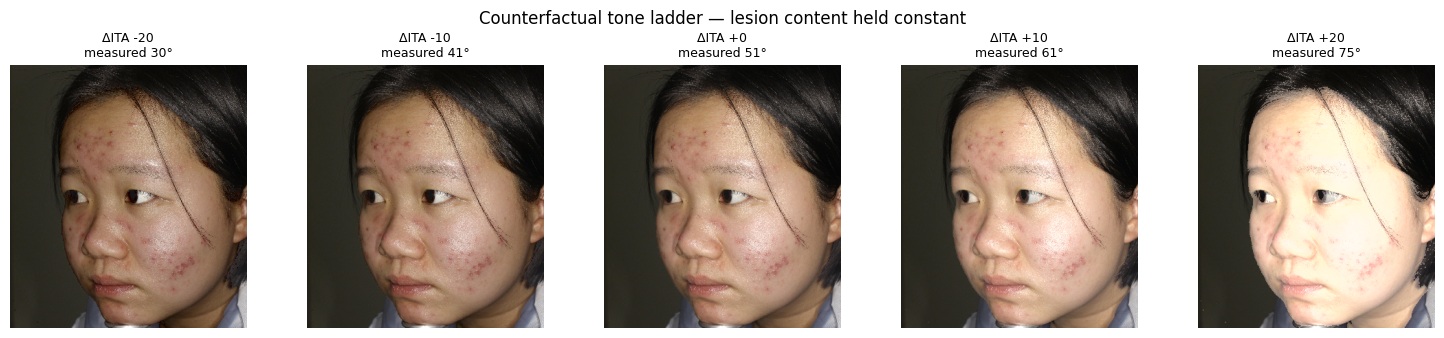

Inspect: acne lesions should look IDENTICAL across the row; only tone moves.


In [4]:
demo = paths[0]
img = load_bgr(demo); m = skin_mask(img)
fig, axes = plt.subplots(1, len(SHIFTS), figsize=(3 * len(SHIFTS), 3.4))
for ax, d in zip(axes, SHIFTS):
    sh, dL = shift_tone(img, m, d)
    ita_after, _, _ = measure_ita(sh, m)
    ax.imshow(cv2.cvtColor(sh, cv2.COLOR_BGR2RGB)); ax.axis("off")
    ax.set_title(f"ΔITA {d:+d}\nmeasured {ita_after:.0f}°", fontsize=9)
plt.suptitle("Counterfactual tone ladder — lesion content held constant")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "rq4_shift_example.png"), dpi=120)
plt.show()
print("Inspect: acne lesions should look IDENTICAL across the row; only tone moves.")

## 4. Run the probe across the corpus

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tf = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(MEAN, STD)])


class ShiftDS(Dataset):
    """Yields every (image, shift) pair as a tensor."""
    def __init__(self, paths, shifts):
        self.items = [(p, s) for p in paths for s in shifts]
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        p, s = self.items[i]
        img = load_bgr(p)
        if img is None:
            return torch.zeros(3, 224, 224), p, s, np.nan, -1
        m = skin_mask(img)
        base_ita, _, _ = measure_ita(img, m)
        sh, _ = shift_tone(img, m, s)
        pil = Image.fromarray(cv2.cvtColor(sh, cv2.COLOR_BGR2RGB))
        return tf(pil), p, s, float(base_ita), acne_label(p)


def collate(b):
    xs, ps, ss, its, ls = zip(*b)
    return torch.stack(xs), list(ps), list(ss), list(its), list(ls)


ds = ShiftDS(paths, SHIFTS)
dl = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2,
                collate_fn=collate, pin_memory=True)
print(f"forward passes: {len(ds)} ({len(paths)} images x {len(SHIFTS)} shifts)")

rows = []
with torch.no_grad():
    for bi, (x, ps, ss, its, ls) in enumerate(dl):
        x = x.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
            prob = torch.softmax(model(x), 1).float().cpu().numpy()
        pred = prob.argmax(1)
        for j in range(len(ps)):
            rows.append(dict(path=ps[j], shift=ss[j], base_ita=its[j],
                             y_true=ls[j], y_pred=int(pred[j]),
                             confidence=float(prob[j].max()),
                             expected_severity=float((prob[j] *
                                                      np.arange(n_cls)).sum())))
        if (bi + 1) % 20 == 0:
            print(f"  batch {bi+1}/{len(dl)}")
probe = pd.DataFrame(rows)
probe.to_csv(os.path.join(WORK, "rq4_counterfactual_predictions.csv"),
             index=False)
print("saved rq4_counterfactual_predictions.csv", probe.shape)

forward passes: 7285 (1457 images x 5 shifts)
  batch 20/228
  batch 40/228
  batch 60/228
  batch 80/228
  batch 100/228
  batch 120/228
  batch 140/228
  batch 160/228
  batch 180/228
  batch 200/228
  batch 220/228
saved rq4_counterfactual_predictions.csv (7285, 7)


## 5. Did tone alone change the prediction?


| dITA | flip rate | d expected severity | d confidence |
|---|---|---|---|
| -20 |   6.8% [5.5, 8.2] | +0.0556 [+0.0461, +0.0652] | -0.0206 |
| -10 |   3.6% [2.6, 4.5] | +0.0193 [+0.0134, +0.0261] | -0.0100 |
| +0 |   0.0% [0.0, 0.0] | +0.0000 [+0.0000, +0.0000] | +0.0000 |
| +10 |   5.4% [4.2, 6.6] | -0.0049 [-0.0141, +0.0047] | -0.0223 |
| +20 |  20.1% [17.8, 22.0] | +0.1036 [+0.0815, +0.1261] | -0.0954 |

Darkening  (-20): +0.0556 [+0.0467, +0.0662]
Lightening (+20): +0.1036 [+0.0813, +0.1259]

Causal tone sensitivity: YES


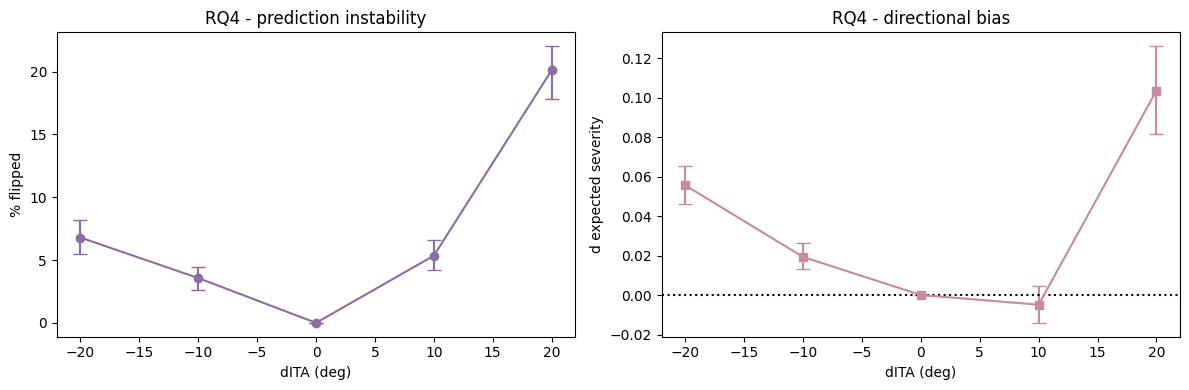


Saved: rq4_summary.csv, rq4_result.json, rq4_tone_sensitivity.png


In [7]:
import numpy as np, pandas as pd, json, os, matplotlib.pyplot as plt
WORK = "/kaggle/working"; RNG = np.random.default_rng(42)

if "probe" not in dir():
    probe = pd.read_csv(f"{WORK}/rq4_counterfactual_predictions.csv")
probe = probe.rename(columns={"shift": "ita_shift"})
SHIFTS = sorted(probe["ita_shift"].unique())

base = probe[probe["ita_shift"] == 0].set_index("path")
probe["pred_base"]  = probe["path"].map(base["y_pred"])
probe["conf_base"]  = probe["path"].map(base["confidence"])
probe["exp_base"]   = probe["path"].map(base["expected_severity"])
probe["flipped"]    = (probe.y_pred != probe.pred_base).astype(int)
probe["d_expected"] = probe.expected_severity - probe.exp_base
probe["d_conf"]     = probe.confidence - probe.conf_base

def boot_mean(v, b=1000):
    v = np.asarray(pd.Series(v).dropna(), float)
    if len(v) == 0: return (np.nan, np.nan, np.nan)
    bs = v[RNG.integers(0, len(v), size=(b, len(v)))].mean(axis=1)
    return (v.mean(), *np.percentile(bs, [2.5, 97.5]))

print("\n| dITA | flip rate | d expected severity | d confidence |")
print("|---|---|---|---|")
rows = []
for s in SHIFTS:
    sub = probe[probe["ita_shift"] == s]
    fr, de, dc = boot_mean(sub.flipped), boot_mean(sub.d_expected), boot_mean(sub.d_conf)
    rows.append(dict(ita_shift=s, flip=fr[0], flip_lo=fr[1], flip_hi=fr[2],
                     dexp=de[0], dexp_lo=de[1], dexp_hi=de[2], dconf=dc[0]))
    print(f"| {s:+d} | {100*fr[0]:5.1f}% [{100*fr[1]:.1f}, {100*fr[2]:.1f}] | "
          f"{de[0]:+.4f} [{de[1]:+.4f}, {de[2]:+.4f}] | {dc[0]:+.4f} |")
summ = pd.DataFrame(rows)

dd = boot_mean(probe[probe["ita_shift"] == min(SHIFTS)]["d_expected"])
ll = boot_mean(probe[probe["ita_shift"] == max(SHIFTS)]["d_expected"])
print(f"\nDarkening  ({min(SHIFTS):+d}): {dd[0]:+.4f} [{dd[1]:+.4f}, {dd[2]:+.4f}]")
print(f"Lightening ({max(SHIFTS):+d}): {ll[0]:+.4f} [{ll[1]:+.4f}, {ll[2]:+.4f}]")
sig = (not (dd[1] <= 0 <= dd[2])) or (not (ll[1] <= 0 <= ll[2]))
print(f"\nCausal tone sensitivity: {'YES' if sig else 'NO (CIs include zero)'}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].errorbar(summ["ita_shift"], 100*summ.flip,
               yerr=[100*(summ.flip-summ.flip_lo), 100*(summ.flip_hi-summ.flip)],
               fmt="o-", capsize=5, color="#8a6ea3")
ax[0].set_xlabel("dITA (deg)"); ax[0].set_ylabel("% flipped")
ax[0].set_title("RQ4 - prediction instability")
ax[1].errorbar(summ["ita_shift"], summ.dexp,
               yerr=[summ.dexp-summ.dexp_lo, summ.dexp_hi-summ.dexp],
               fmt="s-", capsize=5, color="#c98a9b")
ax[1].axhline(0, color="k", ls=":"); ax[1].set_xlabel("dITA (deg)")
ax[1].set_ylabel("d expected severity"); ax[1].set_title("RQ4 - directional bias")
plt.tight_layout(); plt.savefig(f"{WORK}/rq4_tone_sensitivity.png", dpi=120); plt.show()

summ.to_csv(f"{WORK}/rq4_summary.csv", index=False)
probe.to_csv(f"{WORK}/rq4_counterfactual_predictions.csv", index=False)
json.dump(dict(flip_rate={int(r.ita_shift): float(r.flip) for r in summ.itertuples()},
               darken=list(map(float, dd)), lighten=list(map(float, ll)),
               causal_sensitivity=bool(sig)),
          open(f"{WORK}/rq4_result.json", "w"), indent=2)
print("\nSaved: rq4_summary.csv, rq4_result.json, rq4_tone_sensitivity.png")

## 6. Figures + save

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(summ.shift, 100 * summ.flip,
                 yerr=[100*(summ.flip - summ.flip_lo),
                       100*(summ.flip_hi - summ.flip)],
                 fmt="o-", capsize=5, color="#8a6ea3")
axes[0].set_xlabel("ΔITA (degrees)"); axes[0].set_ylabel("% predictions flipped")
axes[0].set_title("RQ4 — prediction instability under tone shift")
axes[1].errorbar(summ.shift, summ.dexp,
                 yerr=[summ.dexp - summ.dexp_lo, summ.dexp_hi - summ.dexp],
                 fmt="s-", capsize=5, color="#c98a9b")
axes[1].axhline(0, color="k", ls=":")
axes[1].set_xlabel("ΔITA (degrees)")
axes[1].set_ylabel("Δ expected severity")
axes[1].set_title("RQ4 — directional tone bias")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "rq4_tone_sensitivity.png"), dpi=120)
plt.show()

summ.to_csv(os.path.join(WORK, "rq4_summary.csv"), index=False)
with open(os.path.join(WORK, "rq4_result.json"), "w") as fh:
    json.dump(dict(shifts=SHIFTS,
                   flip_rate={int(r.shift): float(r.flip) for r in summ.itertuples()},
                   darken_d_expected=list(map(float, dd)),
                   lighten_d_expected=list(map(float, ll)),
                   causal_sensitivity=bool(dir_sig)), fh, indent=2)
print("\nSaved: rq4_counterfactual_predictions.csv, rq4_summary.csv, "
      "rq4_result.json, rq4_tone_sensitivity.png, rq4_shift_example.png")
print("\nDOWNLOAD THESE before the session ends (or Save & Run All to persist).")


=== RQ4: prediction change induced by TONE ALONE ===

| dITA | flip rate | d expected severity | d confidence |
|---|---|---|---|
| -20 |   6.8% [5.5, 8.2] | +0.0556 [+0.0461, +0.0652] | -0.0206 |
| -10 |   3.6% [2.6, 4.5] | +0.0193 [+0.0134, +0.0261] | -0.0100 |
| +0 |   0.0% [0.0, 0.0] | +0.0000 [+0.0000, +0.0000] | +0.0000 |
| +10 |   5.4% [4.2, 6.6] | -0.0049 [-0.0141, +0.0047] | -0.0223 |
| +20 |  20.1% [17.8, 22.0] | +0.1036 [+0.0815, +0.1261] | -0.0954 |

Darkening (-20): d expected severity +0.0556 [+0.0467, +0.0662]
Lightening (+20): d expected severity +0.1036 [+0.0813, +0.1259]

Causal tone sensitivity: YES - prediction moves with tone alone


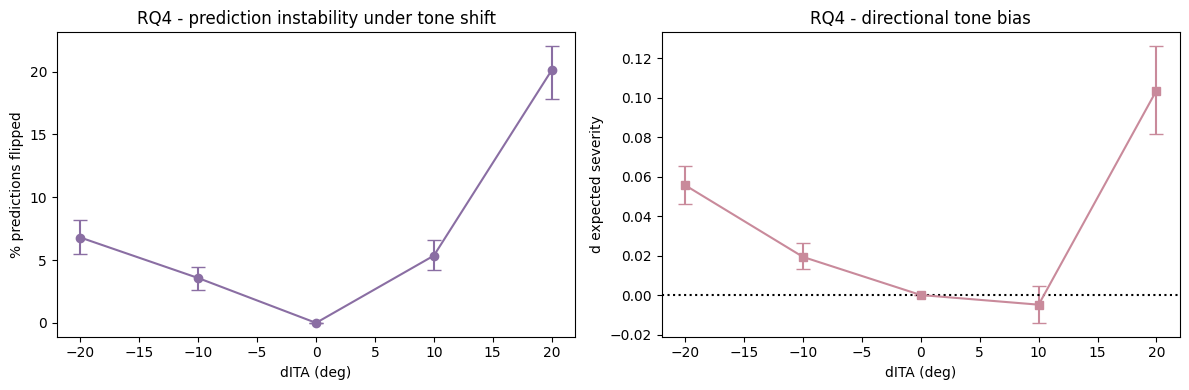


Saved: rq4_summary.csv, rq4_result.json, rq4_tone_sensitivity.png


In [8]:
# --- RQ4 analysis (fixed: 'shift' collided with DataFrame.shift method) ---
import numpy as np, pandas as pd, json, os, matplotlib.pyplot as plt
WORK = "/kaggle/working"
RNG = np.random.default_rng(42)

if "probe" not in dir():
    probe = pd.read_csv(os.path.join(WORK, "rq4_counterfactual_predictions.csv"))
if "shift" in probe.columns:
    probe = probe.rename(columns={"shift": "ita_shift"})
SHIFTS = sorted(probe["ita_shift"].unique())

base = probe[probe["ita_shift"] == 0].set_index("path")
probe["pred_base"]  = probe["path"].map(base["y_pred"])
probe["conf_base"]  = probe["path"].map(base["confidence"])
probe["exp_base"]   = probe["path"].map(base["expected_severity"])
probe["flipped"]    = (probe.y_pred != probe.pred_base).astype(int)
probe["d_expected"] = probe.expected_severity - probe.exp_base
probe["d_conf"]     = probe.confidence - probe.conf_base

def boot_mean(v, b=1000):
    v = np.asarray(pd.Series(v).dropna(), float)
    if len(v) == 0: return (np.nan, np.nan, np.nan)
    bs = v[RNG.integers(0, len(v), size=(b, len(v)))].mean(axis=1)
    return (v.mean(), *np.percentile(bs, [2.5, 97.5]))

print("\n=== RQ4: prediction change induced by TONE ALONE ===\n")
print("| dITA | flip rate | d expected severity | d confidence |")
print("|---|---|---|---|")
summary = []
for s in SHIFTS:
    sub = probe[probe["ita_shift"] == s]
    fr, de, dc = boot_mean(sub.flipped), boot_mean(sub.d_expected), boot_mean(sub.d_conf)
    summary.append(dict(ita_shift=s, flip=fr[0], flip_lo=fr[1], flip_hi=fr[2],
                        dexp=de[0], dexp_lo=de[1], dexp_hi=de[2], dconf=dc[0]))
    print(f"| {s:+d} | {100*fr[0]:5.1f}% [{100*fr[1]:.1f}, {100*fr[2]:.1f}] | "
          f"{de[0]:+.4f} [{de[1]:+.4f}, {de[2]:+.4f}] | {dc[0]:+.4f} |")
summ = pd.DataFrame(summary)

dark  = probe[probe["ita_shift"] == min(SHIFTS)]["d_expected"]
light = probe[probe["ita_shift"] == max(SHIFTS)]["d_expected"]
dd, ll = boot_mean(dark), boot_mean(light)
print(f"\nDarkening ({min(SHIFTS)}): d expected severity {dd[0]:+.4f} [{dd[1]:+.4f}, {dd[2]:+.4f}]")
print(f"Lightening (+{max(SHIFTS)}): d expected severity {ll[0]:+.4f} [{ll[1]:+.4f}, {ll[2]:+.4f}]")
dir_sig = (not (dd[1] <= 0 <= dd[2])) or (not (ll[1] <= 0 <= ll[2]))
print(f"\nCausal tone sensitivity: {'YES - prediction moves with tone alone' if dir_sig else 'NO - CIs include zero'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(summ["ita_shift"], 100*summ.flip,
                 yerr=[100*(summ.flip-summ.flip_lo), 100*(summ.flip_hi-summ.flip)],
                 fmt="o-", capsize=5, color="#8a6ea3")
axes[0].set_xlabel("dITA (deg)"); axes[0].set_ylabel("% predictions flipped")
axes[0].set_title("RQ4 - prediction instability under tone shift")
axes[1].errorbar(summ["ita_shift"], summ.dexp,
                 yerr=[summ.dexp-summ.dexp_lo, summ.dexp_hi-summ.dexp],
                 fmt="s-", capsize=5, color="#c98a9b")
axes[1].axhline(0, color="k", ls=":")
axes[1].set_xlabel("dITA (deg)"); axes[1].set_ylabel("d expected severity")
axes[1].set_title("RQ4 - directional tone bias")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "rq4_tone_sensitivity.png"), dpi=120); plt.show()

summ.to_csv(os.path.join(WORK, "rq4_summary.csv"), index=False)
probe.to_csv(os.path.join(WORK, "rq4_counterfactual_predictions.csv"), index=False)
with open(os.path.join(WORK, "rq4_result.json"), "w") as fh:
    json.dump(dict(shifts=[int(s) for s in SHIFTS],
                   flip_rate={int(r.ita_shift): float(r.flip) for r in summ.itertuples()},
                   darken_d_expected=list(map(float, dd)),
                   lighten_d_expected=list(map(float, ll)),
                   causal_sensitivity=bool(dir_sig)), fh, indent=2)
print("\nSaved: rq4_summary.csv, rq4_result.json, rq4_tone_sensitivity.png")

In [9]:
import numpy as np
clip_stats = []
for p in paths[:200]:
    img = load_bgr(p); m = skin_mask(img)
    for d in (-20, +20):
        sh, _ = shift_tone(img, m, d)
        lab = cv2.cvtColor(sh, cv2.COLOR_BGR2LAB)
        L = lab[:, :, 0][m]
        clip_stats.append(dict(shift=d, pct_clipped=float((L >= 254).mean())))
import pandas as pd
print(pd.DataFrame(clip_stats).groupby("shift").pct_clipped.mean())

shift
-20    0.000000
 20    0.001901
Name: pct_clipped, dtype: float64
